# XGBoost

In [3]:
from xgboost import XGBRFClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
seed = 42

In [5]:
dataset = pd.read_csv("./datasets/thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")

In [6]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29,False,False,False,False,False,False,False,True,False,...,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,29,False,False,False,False,False,False,False,False,False,...,128.0,NaN,NaN,NaN,False,False,False,False,False,True
2,41,False,False,False,False,False,False,False,False,True,...,NaN,NaN,NaN,11.0,False,False,False,False,False,True
3,36,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,26.0,False,False,False,False,False,True
4,32,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,36.0,False,False,False,False,False,True


In [7]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6547
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      247
hyperthyroid              189
antithyroid_treatment      33
Name: count, dtype: int64

In [8]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [9]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [11]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (6078, 28)
X test: (2605, 28)
Y train: (6078,)
Y test: (2605,)


## Model

In [12]:
xgb = XGBRFClassifier()
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

## Model evaluation

Accuracy: 0.9497120921305182
F1 score: 0.9478354803074814


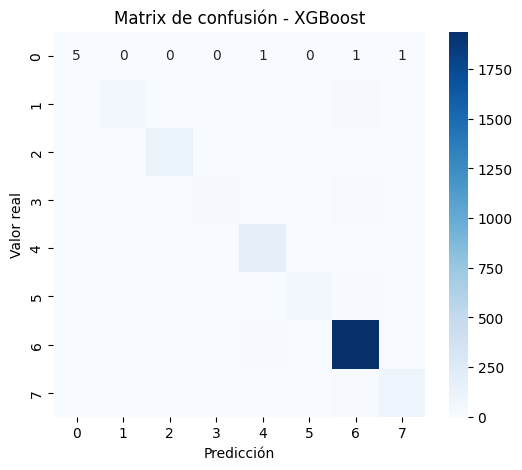

In [13]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - XGBoost')
plt.show()


## Saving model

In [14]:
xgb.save_model("./models_saved/xgboost.json")

## Bayesian optimization

Function that will be used during the optimization

In [15]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        "random_state": seed,
        "n_jobs": -1
    }

    model = XGBRFClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [16]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-17 19:38:25,146] A new study created in memory with name: no-name-8b02fd4e-238c-4034-b37e-0851589df462
[I 2025-04-17 19:38:30,348] Trial 0 finished with value: 0.9398173674136153 and parameters: {'n_estimators': 487, 'max_depth': 5, 'learning_rate': 0.3315810737499465, 'subsample': 0.5277457262052412}. Best is trial 0 with value: 0.9398173674136153.
[I 2025-04-17 19:38:31,788] Trial 1 finished with value: 0.9324630635498757 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.06808374938844276, 'subsample': 0.6882702493119914}. Best is trial 0 with value: 0.9398173674136153.
[I 2025-04-17 19:38:35,893] Trial 2 finished with value: 0.9525300329456909 and parameters: {'n_estimators': 222, 'max_depth': 18, 'learning_rate': 0.20031630765887662, 'subsample': 0.7572456423566474}. Best is trial 2 with value: 0.9525300329456909.
[I 2025-04-17 19:38:40,492] Trial 3 finished with value: 0.9514912169783324 and parameters: {'n_estimators': 209, 'max_depth': 16, 'lear

In [17]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'n_estimators': 76, 'max_depth': 17, 'learning_rate': 0.48548038459854115, 'subsample': 0.8618031811228568}


In [18]:
xgb = XGBRFClassifier(**optimization.best_params)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

In [19]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9550863723608445
F1 score: 0.9543718609234016


In [20]:
xgb.save_model("./models_saved/xgboost_opt.json")